#### Importing the libraries and reading the datasets.

In [44]:
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt

In [5]:
DATASET_FOLDER = Path("../data/interim")

In [31]:
ball_df = pd.read_csv(DATASET_FOLDER / "ball_by_ball.csv") 
match_df = pd.read_csv(DATASET_FOLDER / "match_by_match.csv")

#### Basic Checks about the ball dataset

In [23]:
print("Shape of DataFrame:", ball_df.shape)
print("\nColumns:\n", ball_df.columns)
print("\nData Types:\n", ball_df.dtypes)

Shape of DataFrame: (295732, 11)

Columns:
 Index(['match_id', 'inning', 'batting_team', 'bowling_team', 'over', 'ball',
       'batsman', 'bowler', 'non_striker', 'runs_batsman', 'runs_total'],
      dtype='str')

Data Types:
 match_id        int64
inning            str
batting_team      str
bowling_team      str
over            int64
ball            int64
batsman           str
bowler            str
non_striker       str
runs_batsman    int64
runs_total      int64
dtype: object


In [14]:
print("\nMissing Values:\n", ball_df.isnull().sum())


Missing Values:
 match_id        0
inning          0
batting_team    0
bowling_team    0
over            0
ball            0
batsman         0
bowler          0
non_striker     0
runs_batsman    0
runs_total      0
dtype: int64


In [15]:
ball_df.describe()

,match_id,over,ball,runs_batsman,runs_total
count,2.957320e+05,295732.000000,295732.000000,295732.000000,295732.000000
mean,9.770551e+05,9.190331,3.627916,1.290117,1.358453
std,3.953255e+05,5.679690,1.817997,1.664418,1.650191
min,3.359820e+05,0.000000,1.000000,0.000000,0.000000
25%,5.483720e+05,4.000000,2.000000,0.000000,0.000000
50%,1.082639e+06,9.000000,4.000000,1.000000,1.000000
75%,1.304103e+06,14.000000,5.000000,1.000000,1.000000
max,1.535465e+06,19.000000,11.000000,6.000000,7.000000


There are no missing values in the ball dataset. The basic statistics indicate no notable issues with the dataset, allowing us to proceed with further analysis.

#### Basic Checks about the match dataset.

In [16]:
print("Shape of DataFrame:", match_df.shape)
print("\nColumns:\n", match_df.columns)
print("\nData Types:\n", match_df.dtypes)

Shape of DataFrame: (1243, 13)

Columns:
 Index(['match_id', 'date', 'venue', 'team1', 'team2', 'toss_winner',
       'toss_decision', 'winner', 'result', 'team1_score', 'team2_score',
       'team1_players', 'team2_players'],
      dtype='str')

Data Types:
 match_id         int64
date               str
venue              str
team1              str
team2              str
toss_winner        str
toss_decision      str
winner             str
result             str
team1_score      int64
team2_score      int64
team1_players      str
team2_players      str
dtype: object


In [17]:
print("\nMissing Values:\n", match_df.isnull().sum())


Missing Values:
 match_id          0
date              0
venue             0
team1             0
team2             6
toss_winner       0
toss_decision     0
winner           25
result           25
team1_score       0
team2_score       0
team1_players     0
team2_players     0
dtype: int64


We could see that there are some valyes which are missing in the match dataset.

In [28]:
match_df[match_df["team2"].isna()]

,match_id,date,venue,team1,team2,toss_winner,toss_decision,winner,result,team1_score,team2_score,team1_players,team2_players
417,1359519,2023-05-03,Bharat Ratna Shri Atal Bihari Vajpayee Ekana C...,Lucknow Super Giants,NaN,Chennai Super Kings,field,No Winner,No Result,125,0,"M Vohra, KR Mayers, KS Sharma, KH Pandya, MP S...","AT Rayudu, RD Gaikwad, DP Conway, AM Rahane, M..."
572,1473492,2025-05-05,"Rajiv Gandhi International Stadium, Uppal, Hyd...",Delhi Capitals,NaN,Sunrisers Hyderabad,field,No Winner,No Result,133,0,"KK Nair, F du Plessis, Abishek Porel, KL Rahul...","JD Unadkat, Abhishek Sharma, Ishan Kishan, Sac..."
575,1473495,2025-05-08,"Himachal Pradesh Cricket Association Stadium, ...",Punjab Kings,NaN,Punjab Kings,bat,No Winner,No Result,122,0,"Priyansh Arya, P Simran Singh, JP Inglis, SS I...","F du Plessis, Sameer Rizvi, Abishek Porel, KL ..."
603,1527685,2026-04-06,"Eden Gardens, Kolkata",Kolkata Knight Riders,NaN,Kolkata Knight Riders,bat,No Winner,No Result,25,0,"AM Rahane, FH Allen, C Green, A Raghuvanshi, R...","SS Iyer, P Simran Singh, N Wadhera, C Connolly..."
907,501265,2011-05-21,Feroz Shah Kotla,Delhi Daredevils,NaN,Delhi Daredevils,bat,No Winner,No Result,56,0,"NV Ojha, DA Warner, MS Wade, CA Ingram, Y Venu...","MK Pandey, JP Faulkner, SC Ganguly, RV Uthappa..."
1152,829763,2015-04-29,M Chinnaswamy Stadium,Royal Challengers Bangalore,NaN,Rajasthan Royals,field,No Winner,No Result,200,0,"CH Gayle, V Kohli, AB de Villiers, Mandeep Sin...","AM Rahane, SR Watson, SPD Smith, KK Nair, SV S..."


In [34]:
match_df[match_df["result"].isna()].head()

,match_id,date,venue,team1,team2,toss_winner,toss_decision,winner,result,team1_score,team2_score,team1_players,team2_players
33,1082625,2017-04-29,Saurashtra Cricket Association Stadium,Gujarat Lions,Mumbai Indians,Gujarat Lions,bat,NaN,NaN,153,153,"Ishan Kishan, BB McCullum, SK Raina, AJ Finch,...","PA Patel, JC Buttler, N Rana, RG Sharma, KA Po..."
128,1175365,2019-03-30,Arun Jaitley Stadium,Kolkata Knight Riders,Delhi Capitals,Delhi Capitals,field,NaN,NaN,185,185,"NS Naik, CA Lynn, RV Uthappa, N Rana, KD Karth...","PP Shaw, S Dhawan, SS Iyer, RR Pant, CA Ingram..."
167,1178424,2019-04-30,M.Chinnaswamy Stadium,Royal Challengers Bangalore,Rajasthan Royals,Rajasthan Royals,field,NaN,NaN,62,41,"V Kohli, AB de Villiers, MP Stoinis, H Klaasen...","SV Samson, LS Livingstone, AM Rahane, SPD Smit..."
169,1178426,2019-05-02,Wankhede Stadium,Mumbai Indians,Sunrisers Hyderabad,Mumbai Indians,bat,NaN,NaN,162,162,"RG Sharma, Q de Kock, SA Yadav, E Lewis, HH Pa...","WP Saha, MJ Guptill, MK Pandey, KS Williamson,..."
180,1216493,2020-09-20,Dubai International Cricket Stadium,Delhi Capitals,Kings XI Punjab,Kings XI Punjab,field,NaN,NaN,157,157,"PP Shaw, S Dhawan, SO Hetmyer, SS Iyer, RR Pan...","KL Rahul, MA Agarwal, KK Nair, N Pooran, GJ Ma..."


On further inspection, we can see that these are the matches which got abandoned due to the rain after the first innings. And the matches which also abandoned due to the rain before the first innings.

We can fill the winner and result with the No Result and No Winner for the time being.

In [22]:
match_df["result"] = match_df["result"].fillna("No Result")
match_df["winner"] = match_df["winner"].fillna("No Winner")

In [18]:
match_df.describe()

,match_id,team1_score,team2_score
count,1.243000e+03,1243.000000,1243.000000
mean,9.758619e+05,168.569590,154.377313
std,3.956922e+05,34.053296,35.069657
min,3.359820e+05,25.000000,0.000000
25%,5.483705e+05,148.000000,135.000000
50%,1.082636e+06,168.000000,157.000000
75%,1.304102e+06,190.000000,177.000000
max,1.535465e+06,287.000000,265.000000


#### We are inspecting the match venues next

In [50]:
venues = sorted(match_df["venue"].dropna().unique())

print(f"The number of distinct stadium where ipl matches have been played are {len(venues)}\n")
print("The following are the all the values where ipl matches are played:")
for venue in venues:
    print(venue)

The number of distinct stadium where ipl matches have been played are 60

The following are the all the values where ipl matches are played:
Arun Jaitley Stadium
Arun Jaitley Stadium, Delhi
Barabati Stadium
Barsapara Cricket Stadium, Guwahati
Bharat Ratna Shri Atal Bihari Vajpayee Ekana Cricket Stadium, Lucknow
Brabourne Stadium
Brabourne Stadium, Mumbai
Buffalo Park
De Beers Diamond Oval
Dr DY Patil Sports Academy
Dr DY Patil Sports Academy, Mumbai
Dr. Y.S. Rajasekhara Reddy ACA-VDCA Cricket Stadium
Dr. Y.S. Rajasekhara Reddy ACA-VDCA Cricket Stadium, Visakhapatnam
Dubai International Cricket Stadium
Eden Gardens
Eden Gardens, Kolkata
Feroz Shah Kotla
Green Park
Himachal Pradesh Cricket Association Stadium
Himachal Pradesh Cricket Association Stadium, Dharamsala
Holkar Cricket Stadium
JSCA International Stadium Complex
Kingsmead
M Chinnaswamy Stadium
M Chinnaswamy Stadium, Bengaluru
M.Chinnaswamy Stadium
MA Chidambaram Stadium
MA Chidambaram Stadium, Chepauk
MA Chidambaram Stadium, Ch

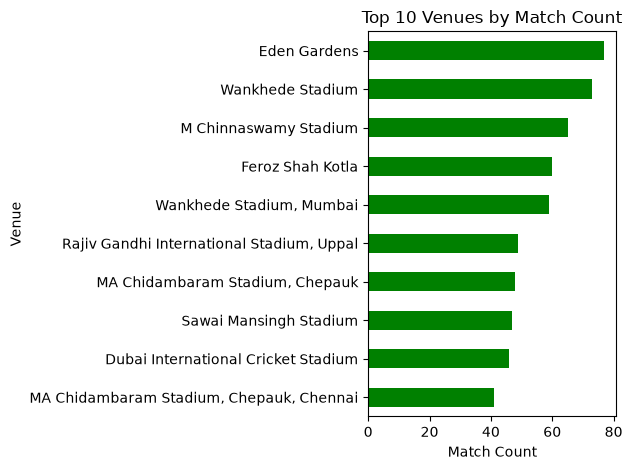

In [45]:
match_df['venue'].value_counts().head(10).plot(kind='barh', title='Top 10 Venues by Match Count', color='green')
plt.xlabel("Match Count")
plt.ylabel("Venue")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

On visual inspection, we can tell that duplicate names and old names of the same venues are present in the dataset. We have to fix that

As there is no automated way to do that. We have to manually change the old stadium's names to their names as well as remove the duplicated version of the same stadium.

In [51]:
venue_replacements = {
    "Arun Jaitley Stadium": "Arun Jaitley Stadium, Delhi",

    "M Chinnaswamy Stadium": "M Chinnaswamy Stadium, Bengaluru",

    "Rajiv Gandhi International Stadium": "Rajiv Gandhi International Stadium, Uppal, Hyderabad",
    "Rajiv Gandhi International Stadium, Uppal": "Rajiv Gandhi International Stadium, Uppal, Hyderabad",

    "Himachal Pradesh Cricket Association Stadium": "Himachal Pradesh Cricket Association Stadium, Dharamsala",

    "Sawai Mansingh Stadium": "Sawai Mansingh Stadium, Jaipur",

    "Dr DY Patil Sports Academy": "Dr DY Patil Sports Academy, Mumbai",

    "Eden Gardens": "Eden Gardens, Kolkata",

    "Punjab Cricket Association IS Bindra Stadium": "Punjab Cricket Association IS Bindra Stadium, Mohali, Chandigarh",
    "Punjab Cricket Association IS Bindra Stadium, Mohali": "Punjab Cricket Association IS Bindra Stadium, Mohali, Chandigarh",
    "Punjab Cricket Association Stadium, Mohali": "Punjab Cricket Association IS Bindra Stadium, Mohali, Chandigarh",

    "Wankhede Stadium": "Wankhede Stadium, Mumbai",

    "MA Chidambaram Stadium": "MA Chidambaram Stadium, Chepauk, Chennai",
    "MA Chidambaram Stadium, Chepauk": "MA Chidambaram Stadium, Chepauk, Chennai", 

    "Brabourne Stadium": "Brabourne Stadium, Mumbai",

    "Dr. Y.S. Rajasekhara Reddy ACA-VDCA Cricket Stadium": "Dr. Y.S. Rajasekhara Reddy ACA-VDCA Cricket Stadium, Visakhapatnam",

    "Maharashtra Cricket Association Stadium": "Maharashtra Cricket Association Stadium, Pune",

    "Feroz Shah Kotla":"Arun Jaitley Stadium, Delhi",

    "Sardar Patel Stadium, Moter": "Narendra Modi Stadium, Ahmedabad", 

    "Sheikh Zayed Stadium" : "Zayed Cricket Stadium, Abu Dhabi"

}
match_df["venue"] = match_df["venue"].replace(venue_replacements)

We have reactified all the anomalies in the venue column of the dataset

In [52]:
venues = sorted(match_df["venue"].dropna().unique())

print(f"The number of distinct stadium where ipl matches have been played are {len(venues)}\n")
print("The following are the all the values where ipl matches are played:")
for venue in venues:
    print(venue)

The number of distinct stadium where ipl matches have been played are 41

The following are the all the values where ipl matches are played:
Arun Jaitley Stadium, Delhi
Barabati Stadium
Barsapara Cricket Stadium, Guwahati
Bharat Ratna Shri Atal Bihari Vajpayee Ekana Cricket Stadium, Lucknow
Brabourne Stadium, Mumbai
Buffalo Park
De Beers Diamond Oval
Dr DY Patil Sports Academy, Mumbai
Dr. Y.S. Rajasekhara Reddy ACA-VDCA Cricket Stadium, Visakhapatnam
Dubai International Cricket Stadium
Eden Gardens, Kolkata
Green Park
Himachal Pradesh Cricket Association Stadium, Dharamsala
Holkar Cricket Stadium
JSCA International Stadium Complex
Kingsmead
M Chinnaswamy Stadium, Bengaluru
M.Chinnaswamy Stadium
MA Chidambaram Stadium, Chepauk, Chennai
Maharaja Yadavindra Singh International Cricket Stadium, Mullanpur
Maharaja Yadavindra Singh International Cricket Stadium, New Chandigarh
Maharashtra Cricket Association Stadium, Pune
Narendra Modi Stadium, Ahmedabad
Nehru Stadium
New Wanderers Stadium
N

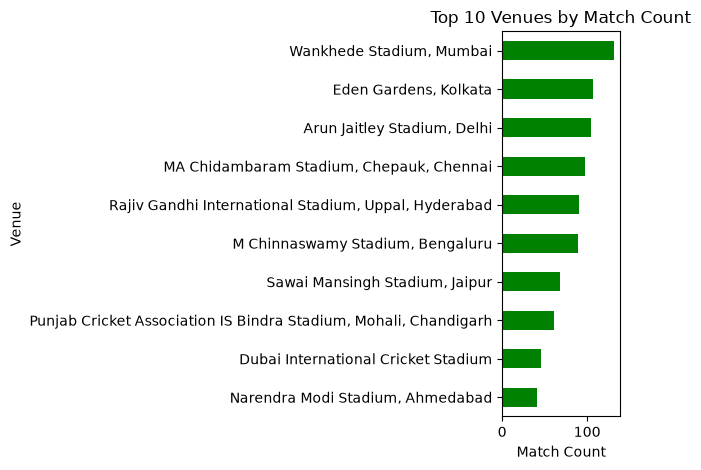

In [53]:
match_df['venue'].value_counts().head(10).plot(kind='barh', title='Top 10 Venues by Match Count', color='green')
plt.xlabel("Match Count")
plt.ylabel("Venue")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

#### We also have to replace the old names of some teams.

These changes must be done in the team1, team2, winner and toss_winner columns of the match dataset.

In [54]:
match_df['team1'] = match_df['team1'].replace({
    'Kings XI Punjab': 'Punjab Kings',
    'Royal Challengers Bangalore': 'Royal Challengers Bengaluru',
    'Delhi Daredevils': 'Delhi Capitals',
    'Rising Pune Supergiant':'Rising Pune Supergiants'
})

match_df['team2'] = match_df['team2'].replace({
    'Kings XI Punjab': 'Punjab Kings',
    'Royal Challengers Bangalore': 'Royal Challengers Bengaluru',
    'Delhi Daredevils': 'Delhi Capitals',
    'Rising Pune Supergiant':'Rising Pune Supergiants'

})

match_df['winner'] = match_df['winner'].replace({
    'Kings XI Punjab': 'Punjab Kings',
    'Royal Challengers Bangalore': 'Royal Challengers Bengaluru',
    'Delhi Daredevils': 'Delhi Capitals',
    'Rising Pune Supergiant':'Rising Pune Supergiants'
})

match_df['toss_winner'] = match_df['toss_winner'].replace({
    'Kings XI Punjab': 'Punjab Kings',
    'Royal Challengers Bangalore': 'Royal Challengers Bengaluru',
    'Delhi Daredevils': 'Delhi Capitals',
    'Rising Pune Supergiant':'Rising Pune Supergiants'
})

#### Doing the same changes in the ball dataset

In [ ]:
ball_df['batting_team'] = ball_df['batting_team'].replace({
    'Kings XI Punjab': 'Punjab Kings',
    'Royal Challengers Bangalore': 'Royal Challengers Bengaluru',
    'Delhi Daredevils': 'Delhi Capitals',
    'Rising Pune Supergiant':'Rising Pune Supergiants'
})

ball_df['bowling_team'] = ball_df['bowling_team'].replace({
    'Kings XI Punjab': 'Punjab Kings',
    'Royal Challengers Bangalore': 'Royal Challengers Bengaluru',
    'Delhi Daredevils': 'Delhi Capitals',
    'Rising Pune Supergiant':'Rising Pune Supergiants'

})